<a href="https://colab.research.google.com/github/DanLincoln24/FrameworksLaba1/blob/main/Laba_2_frameworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Лабораторная работа №2: Анализ временных рядов

# Гаврилов Данила М8О-103БВ-25

## Этап 1. Загрузка и первичный анализ Excel-файла


In [34]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import load_workbook
import warnings
warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')

### Загрузка Excel-файла и просмотр листов

In [4]:
file_path = "/content/drive/MyDrive/have_fun.xlsx"

xl = pd.ExcelFile(file_path)
print(f"Имена листов: {xl.sheet_names}")
print(f"Количество листов: {len(xl.sheet_names)}")

for sheet in xl.sheet_names:
    df_sample = pd.read_excel(xl, sheet_name=sheet, nrows=5)
    print(f"\n Лист: {sheet}")
    print(f"Размер (прочитано): {df_sample.shape}")
    print(df_sample.head())

Имена листов: ['Ëèñò1', 'Лист1', 'ÌÀÈ', 'ýòî', 'ÿ', '!', 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû', 'Ëèñò3_ñìåøàííûå_òèïû']
Количество листов: 8

 Лист: Ëèñò1
Размер (прочитано): (5, 10)
   temperature_2m  relative_humidity_2m  precipitation  rain  snowfall  \
0        3.800000                    82              0     0         0   
1       -3.000000                    70              0     0         0   
2       -1.300000                    86              0     0         0   
3       19.299999                    49              0     0         0   
4        9.600000                    89              0     0         0   

   weathercode  wind_speed_10m  surface_pressure                  ds  \
0            3       19.100000       1010.000000 2020-01-31 02:00:00   
1            3       24.000000        981.900024 2025-02-28 09:00:00   
2            2        8.800000       1021.200012 2022-01-03 02:00:00   
3            0       22.799999       1016.200012 2020-09-17 06:00:00   
4            0      

### Исправление кодировки и анализ структуры данных

#### Проблема: названия городов отображаются кракозябрами из-за проблем с кодировкой (Windows-1251 вместо UTF-8).

#### При чтении Excel явно укажем кодировку, либо преобразуем строки после чтения.

In [6]:
def fix_encoding(text):
    if not isinstance(text, str):
        return text
    try:
        return text.encode('latin1').decode('cp1251')
    except:
        try:
            return text.encode('utf-8').decode('cp1251')
        except:
            return text


xl = pd.ExcelFile(file_path)
sheets_to_load = ['Ëèñò1', 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû', 'Ëèñò3_ñìåøàííûå_òèïû']

data_frames = {}

for sheet in sheets_to_load:
    df = pd.read_excel(xl, sheet_name=sheet)

    df.columns = [fix_encoding(col) for col in df.columns]

    if 'city' in df.columns:
        df['city'] = df['city'].apply(fix_encoding)
    data_frames[sheet] = df
    print(f"\nЛист: {sheet} (прочитан)")
    print(f"Размер: {df.shape}")
    print(f"Столбцы: {df.columns.tolist()}")
    print(f"Уникальные города: {df['city'].unique() if 'city' in df.columns else 'Нет колонки city'}")
    print(df.head(3))


Лист: Ëèñò1 (прочитан)
Размер: (125124, 10)
Столбцы: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']
Уникальные города: ['Геленджик' 'Благовещенск' 'БЛАГОВЕЩЕНСК' 'Благовещенс' 'Благовещенскк'
 'благовещенск' 'ГЕЛЕНДЖИК' 'геленджик' 'Геленджикк' 'Геленджи']
   temperature_2m  relative_humidity_2m  precipitation  rain  snowfall  \
0             3.8                    82            0.0   0.0       0.0   
1            -3.0                    70            0.0   0.0       0.0   
2            -1.3                    86            0.0   0.0       0.0   

   weathercode  wind_speed_10m  surface_pressure                  ds  \
0            3            19.1       1010.000000 2020-01-31 02:00:00   
1            3            24.0        981.900024 2025-02-28 09:00:00   
2            2             8.8       1021.200012 2022-01-03 02:00:00   

           city  
0     Геленджик  
1  Благовещенск  
2 

### Загрузка и очистка данных с каждого листа

Наблюдения:
- Лист1: города Геленджик и Благовещенск (есть опечатки в названиях)
- Лист2: города Москва, Находка + много пустых колонок Unnamed
- Лист3: города Санкт-Петербург, Сочи (опечатки)

1. Удалим лишние колонки Unnamed.
2. Приводим названия городов к единому виду (первая буква заглавная, остальные строчные, исправляем опечатки).
3. Объединяем все данные в один DataFrame.

In [7]:
def decode_russian(text):
    if not isinstance(text, str):
        return text
    try:
        return text.encode('latin1').decode('cp1251')
    except:
        return text

sheets = {
    'Лист1': 'Ëèñò1',
    'Лист2': 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû',
    'Лист3': 'Ëèñò3_ñìåøàííûå_òèïû'
}

df_list = []

for sheet_name, sheet_code in sheets.items():
    df = pd.read_excel(file_path, sheet_name=sheet_code)

    df = df.iloc[:, :10]
    df.columns = [col.strip() for col in df.columns]

    df.columns = [decode_russian(col) for col in df.columns]

    if 'city' in df.columns:
        df['city'] = df['city'].apply(decode_russian)

    df['ds'] = pd.to_datetime(df['ds'])

    df_list.append(df)
    print(f"{sheet_name}: {df.shape}")
    print(f"  Города: {df['city'].unique()[:5]}...")

df_all = pd.concat(df_list, ignore_index=True)
print(f"\nОбщий размер: {df_all.shape}")
print(f"Уникальные города после перекодировки: {df_all['city'].unique()}")

Лист1: (125124, 10)
  Города: ['Геленджик' 'Благовещенск' 'БЛАГОВЕЩЕНСК' 'Благовещенс' 'Благовещенскк']...
Лист2: (125169, 10)
  Города: ['Москва' nan 'Мосва' 'Находка']...
Лист3: (122736, 10)
  Города: ['Санкт-Петербург' 'Сочи' 'Сычи' 'Счи' 'Соч']...

Общий размер: (373029, 10)
Уникальные города после перекодировки: ['Геленджик' 'Благовещенск' 'БЛАГОВЕЩЕНСК' 'Благовещенс' 'Благовещенскк'
 'благовещенск' 'ГЕЛЕНДЖИК' 'геленджик' 'Геленджикк' 'Геленджи' 'Москва'
 nan 'Мосва' 'Находка' 'Санкт-Петербург' 'Сочи' 'Сычи' 'Счи' 'Соч']


In [8]:
def normalize_city(name):
    if pd.isna(name):
        return None

    name = str(name).strip()
    if not name:
        return None

    name_lower = name.lower()

    if name_lower in ['геленджик', 'геленджикк', 'геленджи', 'геленджик ']:
        return 'Геленджик'
    if name_lower == 'геленджикк':
        return 'Геленджик'

    if name_lower in ['благовещенск', 'благовещенс', 'благовещенскк', 'благовещенск ', 'благовещенскк ']:
        return 'Благовещенск'

    if name_lower in ['москва', 'мосва']:
        return 'Москва'

    if name_lower == 'находка':
        return 'Находка'

    if name_lower == 'санкт-петербург':
        return 'Санкт-Петербург'

    if name_lower in ['сочи', 'сычи', 'счи', 'соч']:
        return 'Сочи'

    return name.title()

df_all['city'] = df_all['city'].apply(normalize_city)

df_all = df_all.dropna(subset=['city'])


print(f"Размер после удаления пустых городов: {df_all.shape}")
print(f"Уникальные города: {sorted(df_all['city'].unique())}")

print("\nКоличество записей по городам:")
print(df_all['city'].value_counts())

Размер после удаления пустых городов: (370542, 10)
Уникальные города: ['Благовещенск', 'Геленджик', 'Москва', 'Находка', 'Санкт-Петербург', 'Сочи']

Количество записей по городам:
city
Благовещенск       62599
Геленджик          62525
Сочи               61368
Санкт-Петербург    61368
Москва             61365
Находка            61317
Name: count, dtype: int64


### Проверка качества данных

### Обработаем пропуски и дубликаты

In [9]:
numeric_cols = ['temperature_2m', 'relative_humidity_2m', 'precipitation',
                'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure']

print("Пропуски по городам\n")
for city in df_all['city'].unique():
    df_city = df_all[df_all['city'] == city]
    print(f"{city}:")
    print(df_city[numeric_cols].isnull().sum())
    print("-" * 30)

duplicates = df_all.duplicated(subset=['ds', 'city'], keep=False)
print(f"\nКоличество дубликатов (ds+city): {duplicates.sum()}")
if duplicates.sum() > 0:
    print("Примеры дубликатов:")
    print(df_all[duplicates].sort_values(['city', 'ds']).head(10))

Пропуски по городам

Геленджик:
temperature_2m          944
relative_humidity_2m      0
precipitation           606
rain                      0
snowfall                  0
weathercode               0
wind_speed_10m          645
surface_pressure          0
dtype: int64
------------------------------
Благовещенск:
temperature_2m          931
relative_humidity_2m      0
precipitation           641
rain                      0
snowfall                  0
weathercode               0
wind_speed_10m          607
surface_pressure          0
dtype: int64
------------------------------
Москва:
temperature_2m          343
relative_humidity_2m      0
precipitation           343
rain                      0
snowfall                  0
weathercode               0
wind_speed_10m          175
surface_pressure          0
dtype: int64
------------------------------
Находка:
temperature_2m          336
relative_humidity_2m      0
precipitation           343
rain                      0
snowfall             

### Анализ временной регулярности и удаление дубликатов

In [10]:
df_all = df_all.drop_duplicates(subset=['ds', 'city'], keep='first')
print(f"Размер после удаления дубликатов: {df_all.shape}")

print("\n Анализ временных меток")
print(f"Диапазон дат: {df_all['ds'].min()} - {df_all['ds'].max()}")

df_all['hour'] = df_all['ds'].dt.hour
print(f"Уникальные часы в данных: {sorted(df_all['hour'].unique())}")

for city in df_all['city'].unique():
    df_city = df_all[df_all['city'] == city].copy()
    df_city = df_city.set_index('ds').sort_index()
    date_range = pd.date_range(start=df_city.index.min(), end=df_city.index.max(), freq='D')
    print(f"\n{city}:")
    print(f"  Всего уникальных дат: {df_city.index.nunique()}")
    print(f"  Ожидаемое количество дней: {len(date_range)}")
    print(f"  Пропущено дней: {len(date_range) - df_city.index.nunique()}")
    print(f"  Пример часов: {df_city['hour'].value_counts().head(3)}")

Размер после удаления дубликатов: (368091, 10)

 Анализ временных меток
Диапазон дат: 2019-01-01 00:00:00 - 2025-12-31 23:00:00
Уникальные часы в данных: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(nan)]

Геленджик:
  Всего уникальных дат: 61337
  Ожидаемое количество дней: 2557
  Пропущено дней: -58780
  Пример часов: hour
0.0    2557
2.0    2557
3.0    2557
Name: count, dtype: int64

Благовещенск:
  Всего уникальных дат: 61336
  Ожидаемое количество дней: 2557
  Пропущено дней: -58779
  Пример часов: hour
2.0    2557
7.0    2557
6.0    2557
Name: count, dtype: int64

Москва:
  Всего уникальных дат: 61

### Очистка временных меток: удаление NaN часов и создание регулярного ряда

In [11]:
df_all = df_all.dropna(subset=['hour'])
print(f"Размер после удаления NaN в часе: {df_all.shape}")

full_index = pd.date_range(start='2019-01-01 00:00:00', end='2025-12-31 23:00:00', freq='h')

def resample_city(df_city, city_name):
    df_city = df_city.set_index('ds').sort_index()
    df_city = df_city.reindex(full_index)
    numeric_cols = ['temperature_2m', 'relative_humidity_2m', 'precipitation',
                    'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure']
    df_city[numeric_cols] = df_city[numeric_cols].interpolate(method='linear', limit=24)
    df_city['city'] = city_name
    df_city['hour'] = df_city.index.hour
    return df_city

df_clean_list = []
for city in df_all['city'].unique():
    df_city = df_all[df_all['city'] == city].copy()
    df_city_resampled = resample_city(df_city, city)
    df_clean_list.append(df_city_resampled)
    print(f"{city}: исходно {len(df_city)}, после ресемплинга {len(df_city_resampled)}")

df_clean = pd.concat(df_clean_list)
print(f"\nИтоговый размер: {df_clean.shape}")

print("\nПропуски после интерполяции:")
print(df_clean[numeric_cols].isnull().sum())

Размер после удаления NaN в часе: (368090, 11)
Геленджик: исходно 61337, после ресемплинга 61368
Благовещенск: исходно 61336, после ресемплинга 61368
Москва: исходно 61364, после ресемплинга 61368
Находка: исходно 61317, после ресемплинга 61368
Санкт-Петербург: исходно 61368, после ресемплинга 61368
Сочи: исходно 61368, после ресемплинга 61368

Итоговый размер: (368208, 10)

Пропуски после интерполяции:
temperature_2m          2642
relative_humidity_2m       6
precipitation           2279
rain                       6
snowfall                   6
weathercode              118
wind_speed_10m          1695
surface_pressure           6
dtype: int64


### Удаление оставшихся пропусков и финальная очистка

In [12]:
df_clean = df_clean.dropna()
print(f"Размер после удаления NaN: {df_clean.shape}")

df_clean = df_clean.reset_index()
df_clean = df_clean.rename(columns={'index': 'ds'})
dups = df_clean.duplicated(subset=['ds', 'city']).sum()
print(f"Дубликатов (ds+city): {dups}")
if dups > 0:
    df_clean = df_clean.drop_duplicates(subset=['ds', 'city'], keep='first')
    print(f"Размер после удаления дубликатов: {df_clean.shape}")

for city in df_clean['city'].unique():
    df_city = df_clean[df_clean['city'] == city].copy()
    df_city = df_city.set_index('ds').sort_index()
    print(f"{city}: {len(df_city)} записей, с {df_city.index.min()} по {df_city.index.max()}")
    if 'city_data' not in locals():
        city_data = {}
    city_data[city] = df_city

Размер после удаления NaN: (361890, 10)
Дубликатов (ds+city): 0
Геленджик: 59216 записей, с 2019-01-01 00:00:00 по 2025-12-31 23:00:00
Благовещенск: 59217 записей, с 2019-01-01 00:00:00 по 2025-12-31 23:00:00
Москва: 60506 записей, с 2019-01-01 00:00:00 по 2025-12-31 23:00:00
Находка: 60464 записей, с 2019-01-01 00:00:00 по 2025-12-31 02:00:00
Санкт-Петербург: 61235 записей, с 2019-01-01 00:00:00 по 2025-12-31 23:00:00
Сочи: 61252 записей, с 2019-01-01 00:00:00 по 2025-12-31 23:00:00


### Проанализируем временной ряд. Для начала возьмём Москву

Цель: изучить свойства ряда (тренд, сезонность, стационарность) для выбора признаков.

ValueError: could not convert string to float: 'íåò äàííûõ'

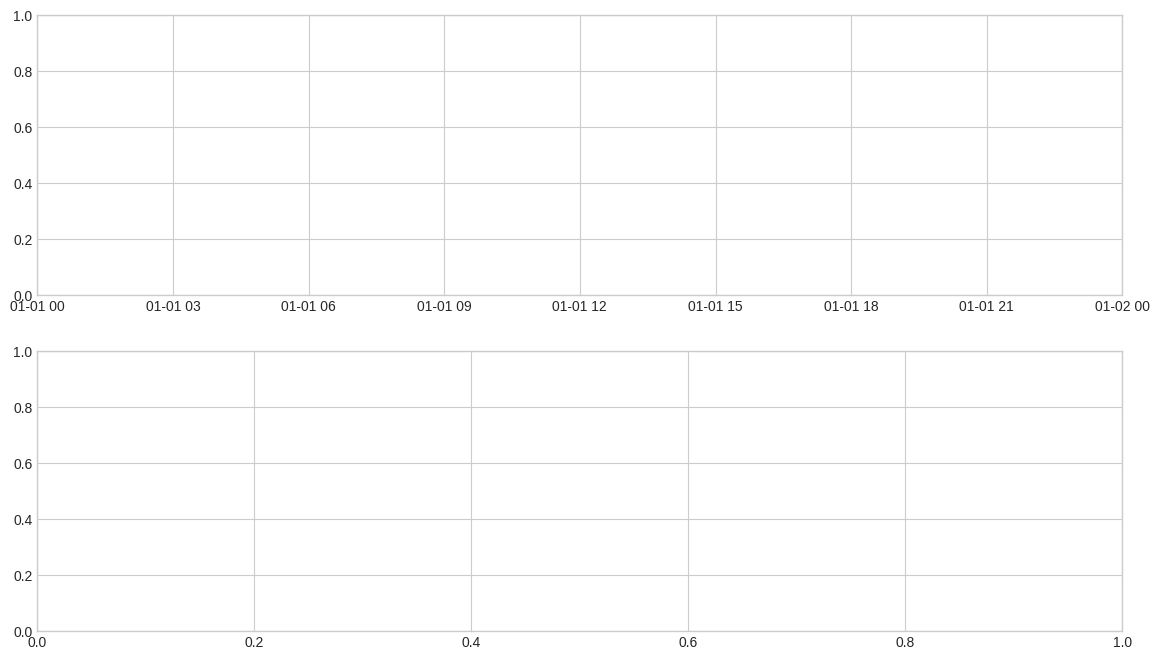

In [13]:
city = 'Москва'
df_moscow = city_data[city].copy()
df_moscow = df_moscow[['temperature_2m']]  # будем предсказывать температуру

# Визуализация
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Исходный ряд
axes[0].plot(df_moscow.index, df_moscow['temperature_2m'], linewidth=0.5, color='steelblue')
axes[0].set_title(f'Температура, {city} (почасовые данные)', fontsize=12)
axes[0].set_ylabel('Температура, °C')
axes[0].grid(True, alpha=0.3)

# Среднесуточная (для сглаживания)
daily_mean = df_moscow['temperature_2m'].resample('D').mean()
axes[1].plot(daily_mean.index, daily_mean, linewidth=1, color='darkorange')
axes[1].set_title('Среднесуточная температура', fontsize=12)
axes[1].set_ylabel('Температура, °C')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Период: {df_moscow.index.min()} - {df_moscow.index.max()}")
print(f"Всего наблюдений: {len(df_moscow)}")
print(f"Среднее: {df_moscow['temperature_2m'].mean():.2f}°C")
print(f"Стандартное отклонение: {df_moscow['temperature_2m'].std():.2f}°C")
print(f"Минимум: {df_moscow['temperature_2m'].min():.1f}°C")
print(f"Максимум: {df_moscow['temperature_2m'].max():.1f}°C")

In [14]:
city = 'Москва'
df_moscow = city_data[city].copy()

print("Типы данных")
print(df_moscow.dtypes)
print("\nПервые 3 строки")
print(df_moscow.head(3))
print("\nТип значений в temperature_2m")
print(type(df_moscow['temperature_2m'].iloc[0]))
print("Значение:", df_moscow['temperature_2m'].iloc[0])

if hasattr(df_moscow['temperature_2m'].iloc[0], '__len__'):
    print("ВНИМАНИЕ: temperature_2m содержит последовательности!")
    print("Длина первого элемента:", len(df_moscow['temperature_2m'].iloc[0]))

Типы данных
temperature_2m           object
relative_humidity_2m    float64
precipitation            object
rain                    float64
snowfall                float64
weathercode              object
wind_speed_10m           object
surface_pressure        float64
city                     object
hour                      int32
dtype: object

Первые 3 строки
                    temperature_2m  relative_humidity_2m precipitation  rain  \
ds                                                                             
2019-01-01 00:00:00           -6.5                  92.0             0   0.0   
2019-01-01 01:00:00           -6.8                  92.0             0   0.0   
2019-01-01 02:00:00           -6.8                  92.0             0   0.0   

                     snowfall weathercode wind_speed_10m  surface_pressure  \
ds                                                                           
2019-01-01 00:00:00       0.0         3.0           10.8       1000.500000   
20

NaN в temperature_2m после приведения: 258
Колонка precipitation: примеры уникальных нечисловых значений:
['---' 'íåò äàííûõ' '?' 'NAN']
  -> заменено на numeric, NaN: 272
Колонка weathercode: примеры уникальных нечисловых значений:
[]
  -> заменено на numeric, NaN: 0
Колонка wind_speed_10m: примеры уникальных нечисловых значений:
['?' '---' 'NAN' 'íåò äàííûõ']
  -> заменено на numeric, NaN: 138


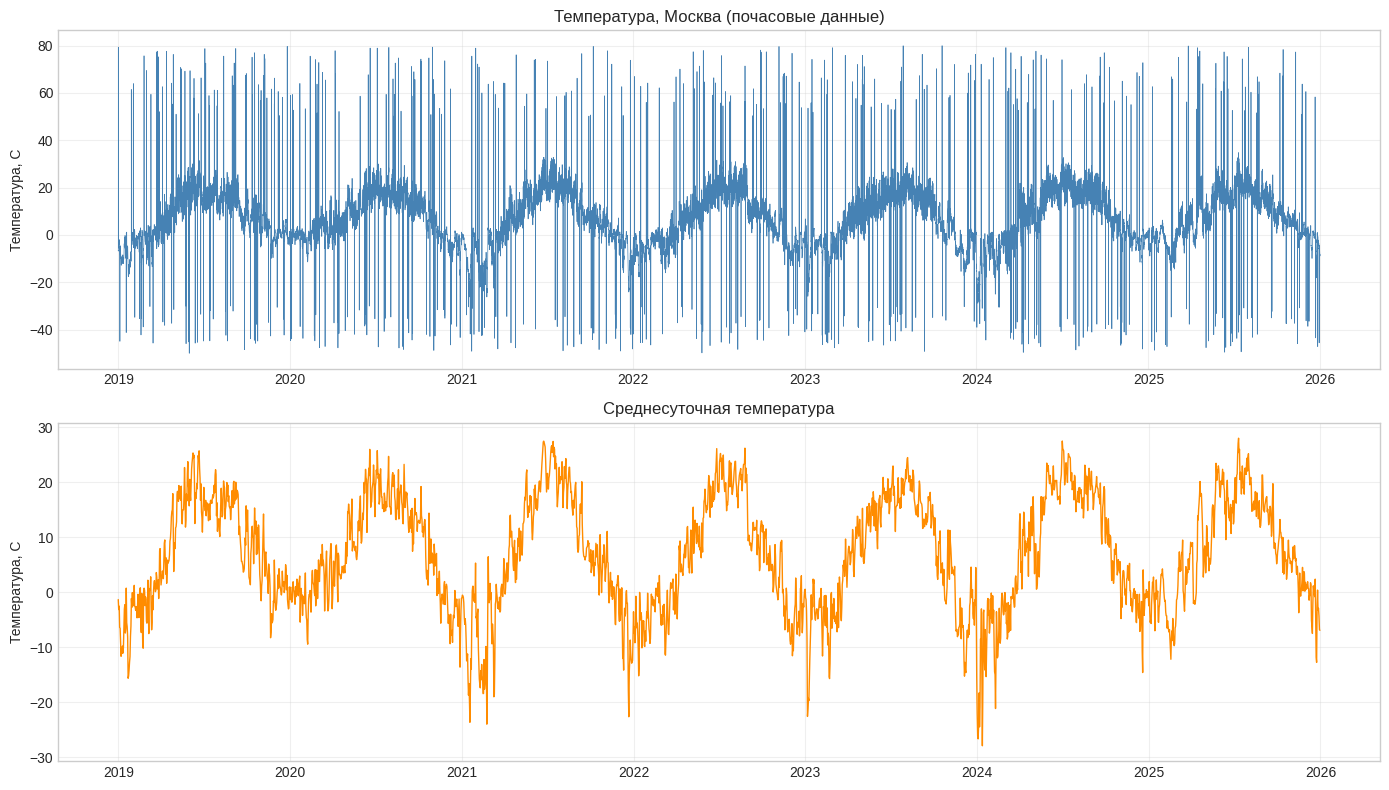

Период: 2019-01-01 00:00:00 - 2025-12-31 23:00:00
Всего наблюдений: 60248


In [15]:
city = 'Москва'
df_moscow = city_data[city].copy()

if isinstance(df_moscow.index[0], tuple):
    df_moscow.index = [t[1] for t in df_moscow.index]

df_moscow['temperature_2m'] = pd.to_numeric(df_moscow['temperature_2m'], errors='coerce')

print(f"NaN в temperature_2m после приведения: {df_moscow['temperature_2m'].isna().sum()}")

for col in ['precipitation', 'weathercode', 'wind_speed_10m']:
    if df_moscow[col].dtype == 'object':
        print(f"Колонка {col}: примеры уникальных нечисловых значений:")
        non_numeric = df_moscow[~df_moscow[col].astype(str).str.replace('.', '').str.isdigit()]
        print(non_numeric[col].unique()[:5])
        df_moscow[col] = pd.to_numeric(df_moscow[col], errors='coerce')
        print(f"  -> заменено на numeric, NaN: {df_moscow[col].isna().sum()}")


df_temp = df_moscow[['temperature_2m']].copy().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df_temp.index, df_temp['temperature_2m'], linewidth=0.5, color='steelblue')
axes[0].set_title(f'Температура, {city} (почасовые данные)', fontsize=12)
axes[0].set_ylabel('Температура, C')
axes[0].grid(True, alpha=0.3)

daily_mean = df_temp['temperature_2m'].resample('D').mean()
axes[1].plot(daily_mean.index, daily_mean, linewidth=1, color='darkorange')
axes[1].set_title('Среднесуточная температура', fontsize=12)
axes[1].set_ylabel('Температура, C')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Период: {df_temp.index.min()} - {df_temp.index.max()}")
print(f"Всего наблюдений: {len(df_temp)}")

temperature_2m: пропусков после очистки = 258
precipitation: пропусков после очистки = 272
weathercode: пропусков после очистки = 0
wind_speed_10m: пропусков после очистки = 138


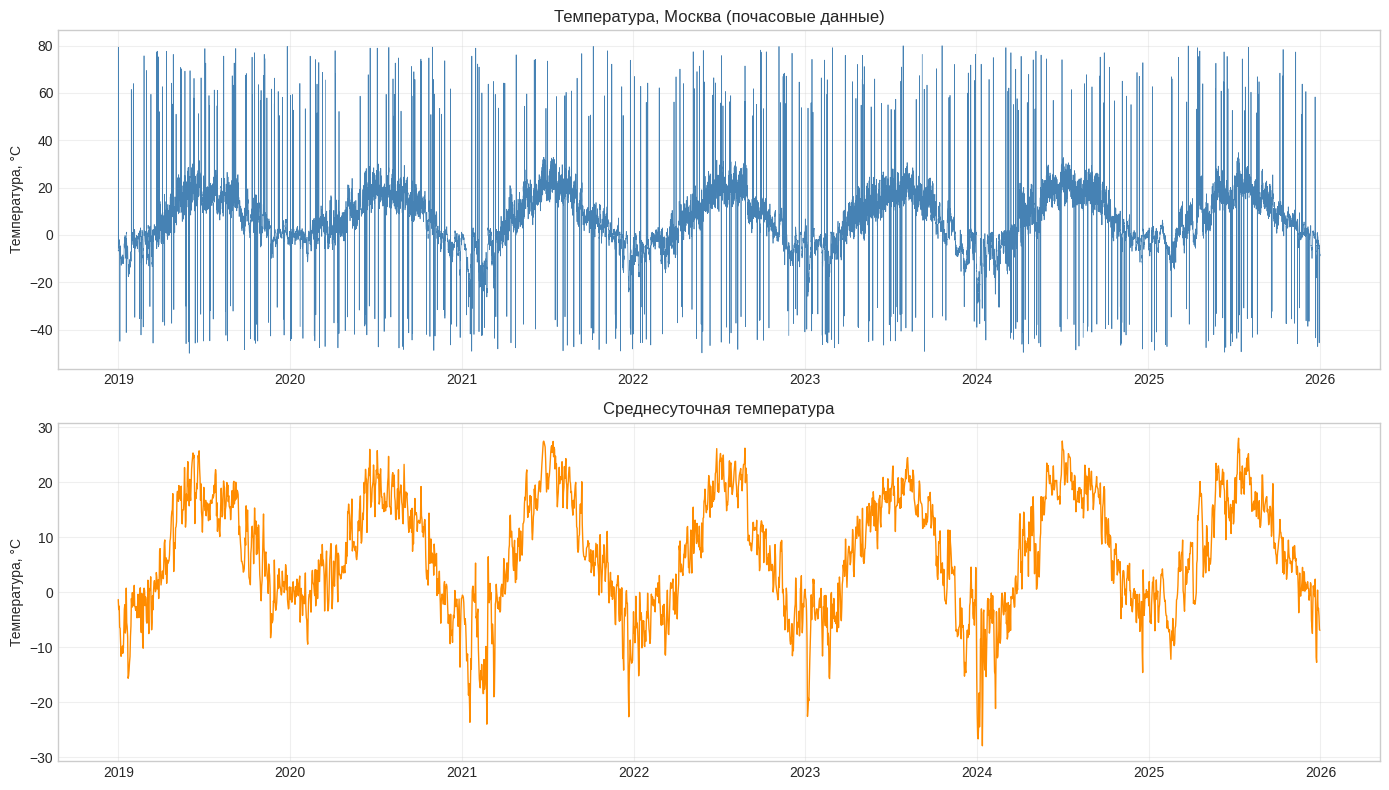

Период: 2019-01-01 00:00:00 - 2025-12-31 23:00:00
Всего наблюдений: 60506
Пропусков в temperature_2m: 258


In [16]:
city = 'Москва'
df_moscow = city_data[city].copy()

if isinstance(df_moscow.index[0], tuple):
    df_moscow.index = [t[1] for t in df_moscow.index]

def clean_numeric(series):
    if series.dtype == 'object':
        series = series.replace(['---', '?', 'NAN', 'нет данных', 'íåò äàííûõ'], np.nan)
        series = pd.to_numeric(series, errors='coerce')
    return series

for col in ['temperature_2m', 'precipitation', 'weathercode', 'wind_speed_10m']:
    df_moscow[col] = clean_numeric(df_moscow[col])
    print(f"{col}: пропусков после очистки = {df_moscow[col].isna().sum()}")

df_temp = df_moscow[['temperature_2m']].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df_temp.index, df_temp['temperature_2m'], linewidth=0.5, color='steelblue')
axes[0].set_title(f'Температура, {city} (почасовые данные)', fontsize=12)
axes[0].set_ylabel('Температура, °C')
axes[0].grid(True, alpha=0.3)

daily_mean = df_temp['temperature_2m'].resample('D').mean()
axes[1].plot(daily_mean.index, daily_mean, linewidth=1, color='darkorange')
axes[1].set_title('Среднесуточная температура', fontsize=12)
axes[1].set_ylabel('Температура, °C')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Период: {df_temp.index.min()} - {df_temp.index.max()}")
print(f"Всего наблюдений: {len(df_temp)}")
print(f"Пропусков в temperature_2m: {df_temp['temperature_2m'].isna().sum()}")

In [17]:
city = 'Москва'
df_moscow = city_data[city].copy()

if isinstance(df_moscow.index[0], tuple):
    df_moscow.index = [t[1] for t in df_moscow.index]

def clean_numeric(series):
    if series.dtype == 'object':
        series = series.replace(['---', '?', 'NAN', 'нет данных', 'íåò äàííûõ'], np.nan)
        series = pd.to_numeric(series, errors='coerce')
    return series

for col in ['temperature_2m', 'precipitation', 'weathercode', 'wind_speed_10m']:
    df_moscow[col] = clean_numeric(df_moscow[col])

df_moscow['temperature_2m'] = df_moscow['temperature_2m'].interpolate(method='linear', limit=24)
print(f"Пропусков после интерполяции: {df_moscow['temperature_2m'].isna().sum()}")

series = df_moscow['temperature_2m'].copy()

from statsmodels.tsa.stattools import adfuller, kpss

adf_result = adfuller(series.dropna(), autolag='AIC')
print(f"\nADF test: p-value = {adf_result[1]:.4f}")
print("  H0: ряд нестационарен")
if adf_result[1] < 0.05:
    print("  -> отвергаем H0, ряд стационарен")
else:
    print("  -> не отвергаем H0, ряд НЕ стационарен")

kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
print(f"\nKPSS test: p-value = {kpss_result[1]:.4f}")
print("  H0: ряд стационарен")
if kpss_result[1] < 0.05:
    print("  -> отвергаем H0, ряд НЕ стационарен")
else:
    print("  -> не отвергаем H0, ряд стационарен")

series_diff = series.diff().dropna()
adf_diff = adfuller(series_diff, autolag='AIC')
print(f"\nADF на разности: p-value = {adf_diff[1]:.4f}")

Пропусков после интерполяции: 0

ADF test: p-value = 0.0000
  H0: ряд нестационарен
  -> отвергаем H0, ряд стационарен

KPSS test: p-value = 0.1000
  H0: ряд стационарен
  -> не отвергаем H0, ряд стационарен


/tmp/ipykernel_2661/1657189357.py:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')



ADF на разности: p-value = 0.0000


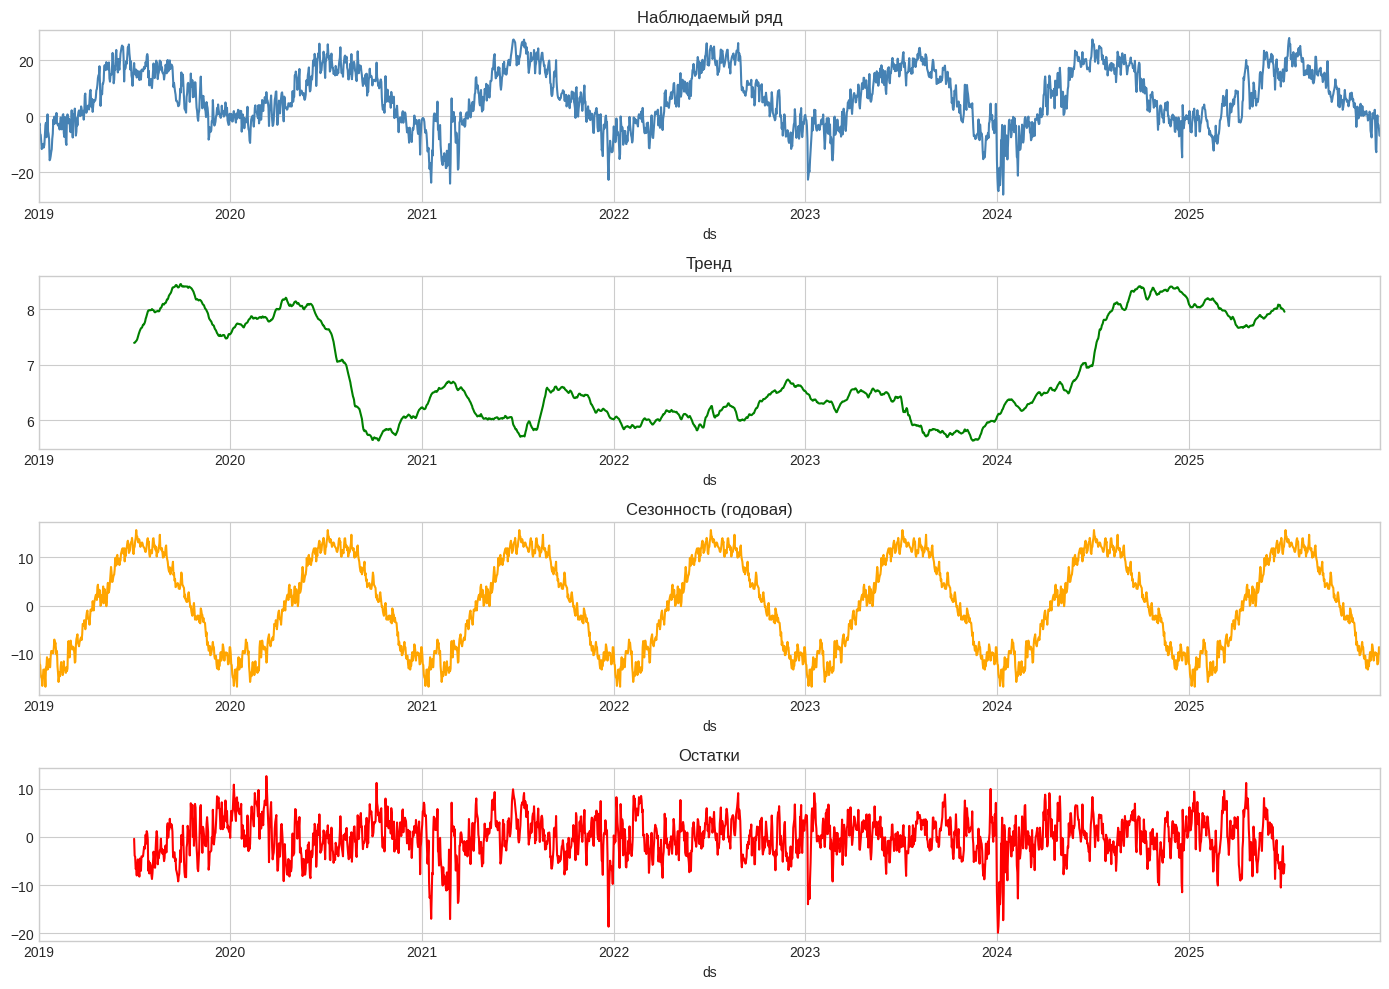

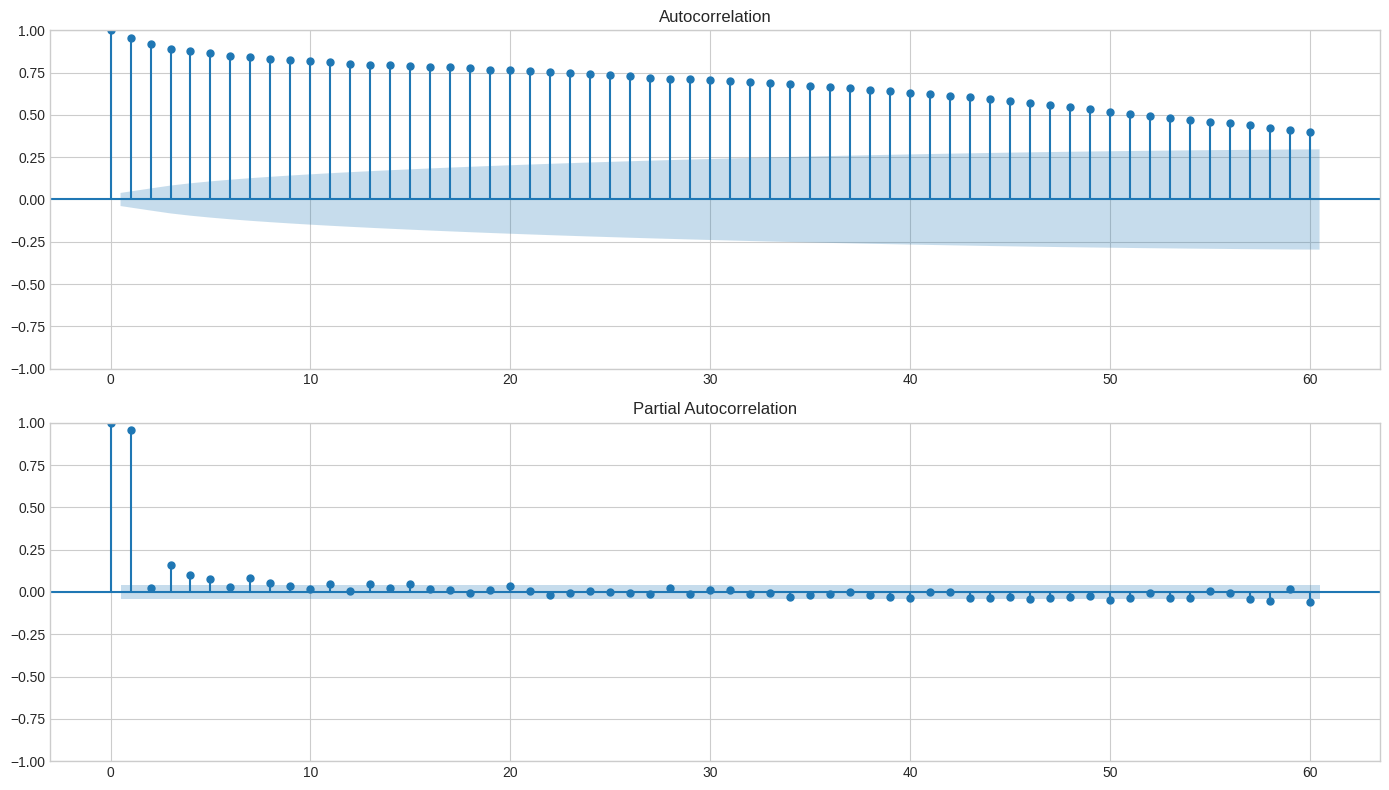

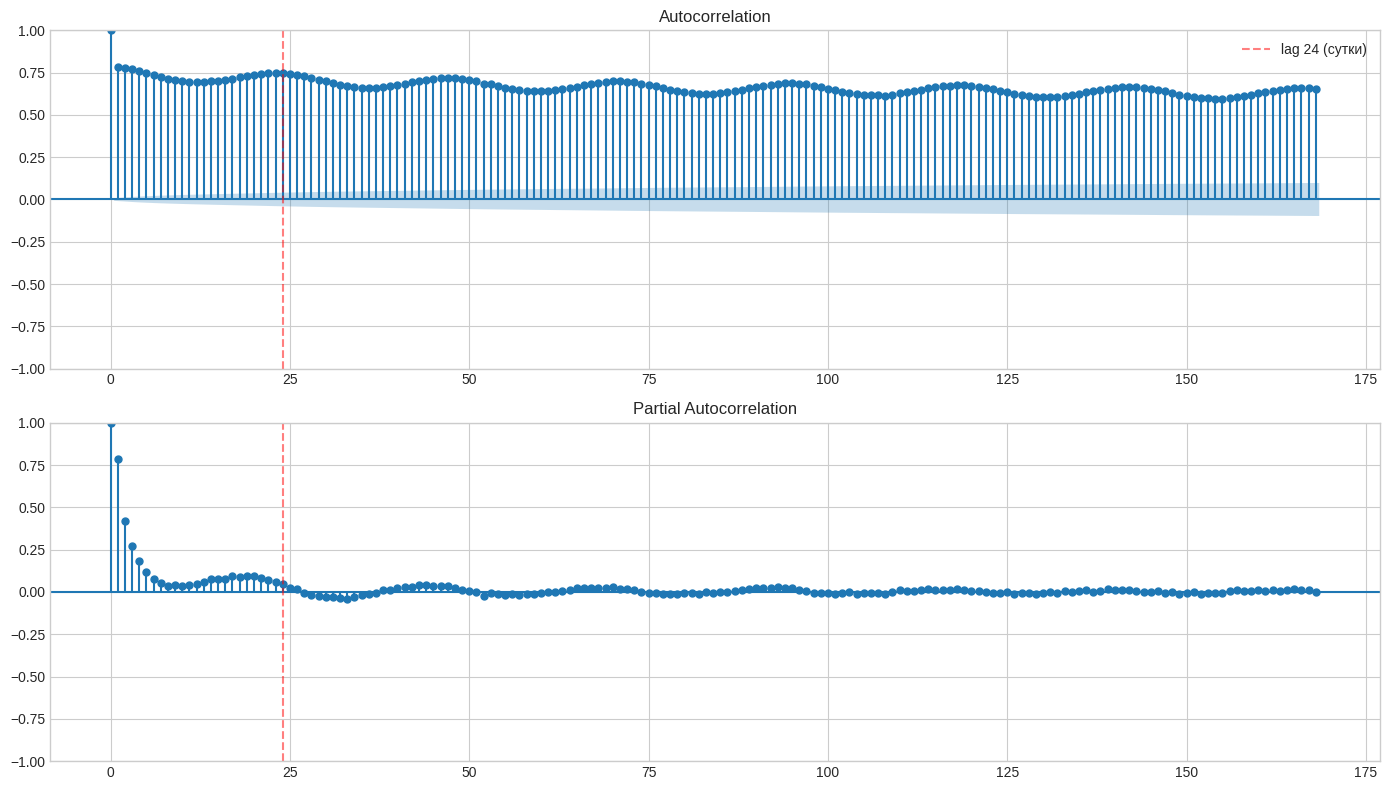

In [18]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

daily_temp = df_moscow['temperature_2m'].resample('D').mean().dropna()

decomp = seasonal_decompose(daily_temp, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomp.observed.plot(ax=axes[0], title='Наблюдаемый ряд', color='steelblue')
decomp.trend.plot(ax=axes[1], title='Тренд', color='green')
decomp.seasonal.plot(ax=axes[2], title='Сезонность (годовая)', color='orange')
decomp.resid.plot(ax=axes[3], title='Остатки', color='red')
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(daily_temp, lags=60, ax=ax1)
plot_pacf(daily_temp, lags=60, ax=ax2)
plt.tight_layout()
plt.show()

hourly_series = df_moscow['temperature_2m'].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(hourly_series, lags=168, ax=ax1)
plot_pacf(hourly_series, lags=168, ax=ax2)
ax1.axvline(x=24, color='red', linestyle='--', alpha=0.5, label='lag 24 (сутки)')
ax2.axvline(x=24, color='red', linestyle='--', alpha=0.5)
ax1.legend()
plt.tight_layout()
plt.show()

### Подготовка данных для прогноза на 7 дней (168 часов)
Стратегия: рекурсивная (одна модель на шаг 1).
Признаки: лаги, скользящие статистики, временные признаки, разности.
Целевая переменная: температура через 1 час (t+1).
На тесте: рекурсивно прогнозируем на 168 часов, затем агрегируем метрики.

In [19]:
def create_features(df, target_col='temperature_2m', lookback=24*7, horizon=1):

    df = df[[target_col]].copy()
    df = df.rename(columns={target_col: 'y'})

    for lag in [1, 2, 3, 4, 5, 6, 7, 24, 48, 72, 96, 120, 144, 168]:
        df[f'lag_{lag}'] = df['y'].shift(lag)

    for window in [3, 6, 12, 24, 48, 168]:
        df[f'roll_mean_{window}'] = df['y'].shift(1).rolling(window=window).mean()
        df[f'roll_std_{window}'] = df['y'].shift(1).rolling(window=window).std()

    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    df['y_target'] = df['y'].shift(-horizon)

    df = df.dropna()
    return df

df_features = create_features(df_moscow, lookback=168, horizon=1)
print(f"Размер признакового датафрейма: {df_features.shape}")
print(f"Колонки: {df_features.columns.tolist()}")

Размер признакового датафрейма: (60337, 37)
Колонки: ['y', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_24', 'lag_48', 'lag_72', 'lag_96', 'lag_120', 'lag_144', 'lag_168', 'roll_mean_3', 'roll_std_3', 'roll_mean_6', 'roll_std_6', 'roll_mean_12', 'roll_std_12', 'roll_mean_24', 'roll_std_24', 'roll_mean_48', 'roll_std_48', 'roll_mean_168', 'roll_std_168', 'hour', 'dayofweek', 'month', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'y_target']


In [22]:
def prepare_recursive_features(df_raw, max_lag=168):
    df = df_raw.copy()
    for lag in [1, 2, 3, 4, 5, 6, 7, 24, 48, 72, 96, 120, 144, 168]:
        df[f'lag_{lag}'] = df['temperature_2m'].shift(lag)
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    df['target'] = df['temperature_2m'].shift(-1)

    df = df.dropna()
    return df

city = 'Москва'
df_moscow_full = city_data[city].copy()
if isinstance(df_moscow_full.index[0], tuple):
    df_moscow_full.index = [t[1] for t in df_moscow_full.index]

df_moscow_full['temperature_2m'] = clean_numeric(df_moscow_full['temperature_2m'])
df_moscow_full['temperature_2m'] = df_moscow_full['temperature_2m'].interpolate(method='linear', limit=24)

df_feat = prepare_recursive_features(df_moscow_full[['temperature_2m']])

df_feat = df_feat.dropna()

n = len(df_feat)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

train_df = df_feat.iloc[:train_end]
val_df = df_feat.iloc[train_end:val_end]
test_df = df_feat.iloc[val_end:]

feature_cols = [c for c in df_feat.columns if c not in ['target', 'temperature_2m']]
X_train = train_df[feature_cols]
y_train = train_df['target']
X_val = val_df[feature_cols]
y_val = val_df['target']
X_test = test_df[feature_cols]
y_test = test_df['target']

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (36202, 23), Val: (12067, 23), Test: (12068, 23)


Начальная история: 168 часов, с 2023-03-11 03:00:00 по 2023-03-18 02:00:00
Пропуски в initial_hist: 0
MAE: 7.93°C
MAPE: 4.6354


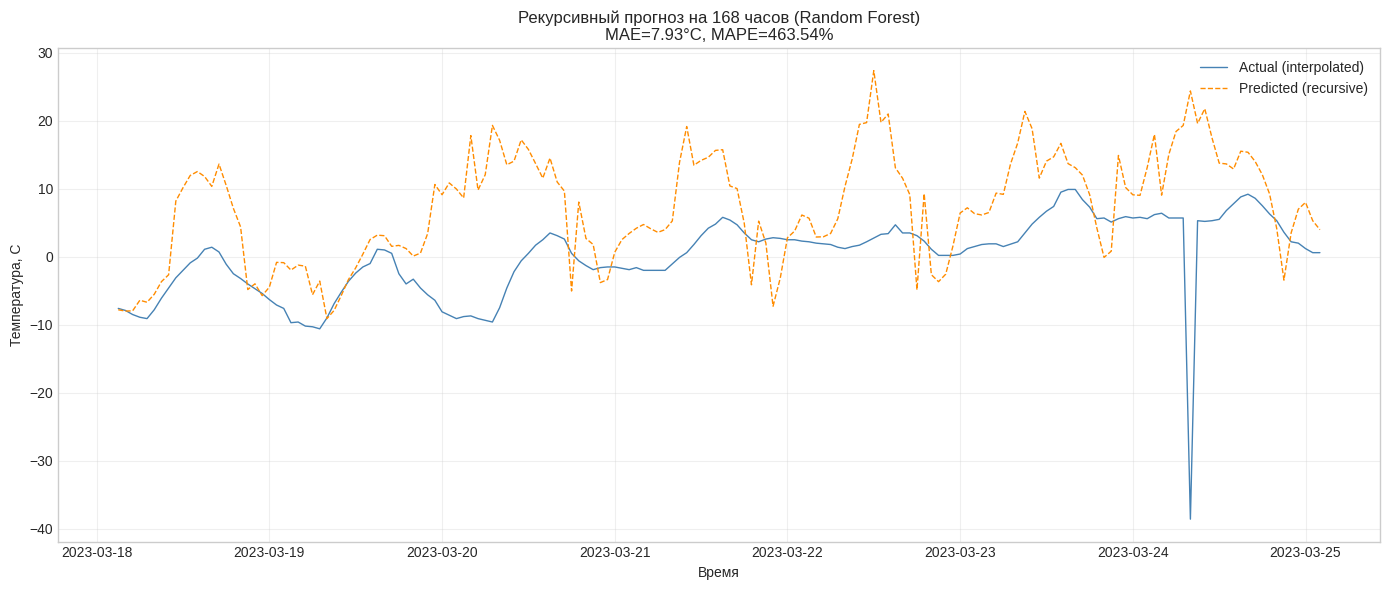

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def clean_and_interpolate(series):
    if series.dtype == 'object':
        series = series.replace(['---', '?', 'NAN', 'нет данных', 'íåò äàííûõ'], np.nan)
        series = pd.to_numeric(series, errors='coerce')
    series = series.interpolate(method='linear', limit=24)
    return series

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

city = 'Москва'
df_moscow = city_data[city].copy()
if isinstance(df_moscow.index[0], tuple):
    df_moscow.index = [t[1] for t in df_moscow.index]

full_index = pd.date_range(start='2019-01-01 00:00:00', end='2025-12-31 23:00:00', freq='h')
temp_full = df_moscow['temperature_2m'].reindex(full_index)
temp_full = clean_and_interpolate(temp_full)

def recursive_forecast(model, initial_history, feature_cols, temp_full_series, horizon=168):
    lag_cols = [c for c in feature_cols if c.startswith('lag_')]
    max_lag = max(int(c.split('_')[1]) for c in lag_cols)

    hist = initial_history.copy()
    preds = []
    pred_times = []
    last_time = initial_history.index[-1]

    for step in range(horizon):
        pred_time = last_time + pd.Timedelta(hours=step+1)
        pred_times.append(pred_time)

        features = {}
        for lag in range(1, max_lag+1):
            col_name = f'lag_{lag}'
            if col_name in feature_cols:
                if len(hist) >= lag:
                    features[col_name] = hist[-lag]
                else:
                    features[col_name] = np.nan

        features['hour'] = pred_time.hour
        features['dayofweek'] = pred_time.dayofweek
        features['month'] = pred_time.month
        features['hour_sin'] = np.sin(2 * np.pi * features['hour'] / 24)
        features['hour_cos'] = np.cos(2 * np.pi * features['hour'] / 24)
        features['dow_sin'] = np.sin(2 * np.pi * features['dayofweek'] / 7)
        features['dow_cos'] = np.cos(2 * np.pi * features['dayofweek'] / 7)
        features['month_sin'] = np.sin(2 * np.pi * features['month'] / 12)
        features['month_cos'] = np.cos(2 * np.pi * features['month'] / 12)

        X_pred = pd.DataFrame([features])[feature_cols]
        pred = model.predict(X_pred)[0]
        preds.append(pred)

        hist = pd.concat([hist, pd.Series([pred], index=[pred_time])])

    actuals = temp_full_series.loc[pred_times].values

    return np.array(preds), actuals, pred_times

max_lag = 168
val_start = val_df.index[0]

initial_hist = temp_full.loc[:val_start - pd.Timedelta(hours=1)].iloc[-max_lag:]

print(f"Начальная история: {len(initial_hist)} часов, с {initial_hist.index[0]} по {initial_hist.index[-1]}")
print("Пропуски в initial_hist:", initial_hist.isna().sum())

preds, actuals, pred_times = recursive_forecast(rf, initial_hist, feature_cols, temp_full, horizon=168)

mask = ~np.isnan(actuals)
preds_clean = preds[mask]
actuals_clean = actuals[mask]
pred_times_clean = [pred_times[i] for i in range(len(pred_times)) if mask[i]]

mae = mean_absolute_error(actuals_clean, preds_clean)
mape = mean_absolute_percentage_error(actuals_clean, preds_clean)
print(f"MAE: {mae:.2f}°C")
print(f"MAPE: {mape:.4f}")

plt.figure(figsize=(14, 6))
plt.plot(pred_times_clean, actuals_clean, label='Actual (interpolated)', color='steelblue', linewidth=1)
plt.plot(pred_times_clean, preds_clean, label='Predicted (recursive)', color='darkorange', linestyle='--', linewidth=1)
plt.title(f'Рекурсивный прогноз на 168 часов (Random Forest)\nMAE={mae:.2f}°C, MAPE={mape:.2%}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel('Время')
plt.ylabel('Температура, C')
plt.tight_layout()
plt.show()

In [28]:
!pip install optuna xgboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.0 MB/s eta 0:00:00


[I 2026-05-29 14:37:06,065] A new study created in memory with name: no-name-37e01147-d1ca-4cfb-ae5c-967524292e9b


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-29 14:37:40,858] Trial 0 finished with value: 2.1422309865951936 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_lambda': 1.6443457513284063, 'reg_alpha': 0.6750277604651747}. Best is trial 0 with value: 2.1422309865951936.
[I 2026-05-29 14:37:48,520] Trial 1 finished with value: 2.0355397166539464 and parameters: {'n_estimators': 447, 'max_depth': 7, 'learning_rate': 0.11114989443094977, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'reg_lambda': 8.341182143924176, 'reg_alpha': 2.202157195714934}. Best is trial 1 with value: 2.0355397166539464.
[I 2026-05-29 14:37:51,516] Trial 2 finished with value: 1.6730819204580347 and parameters: {'n_estimators': 172, 'max_depth': 4, 'learning_rate': 0.028145092716060652, 'subsample': 0.8099025726528951, 'colsample_bytree': 0.7727780074568463, 'reg_lambda': 2.983168487960615, 'reg_alpha': 6

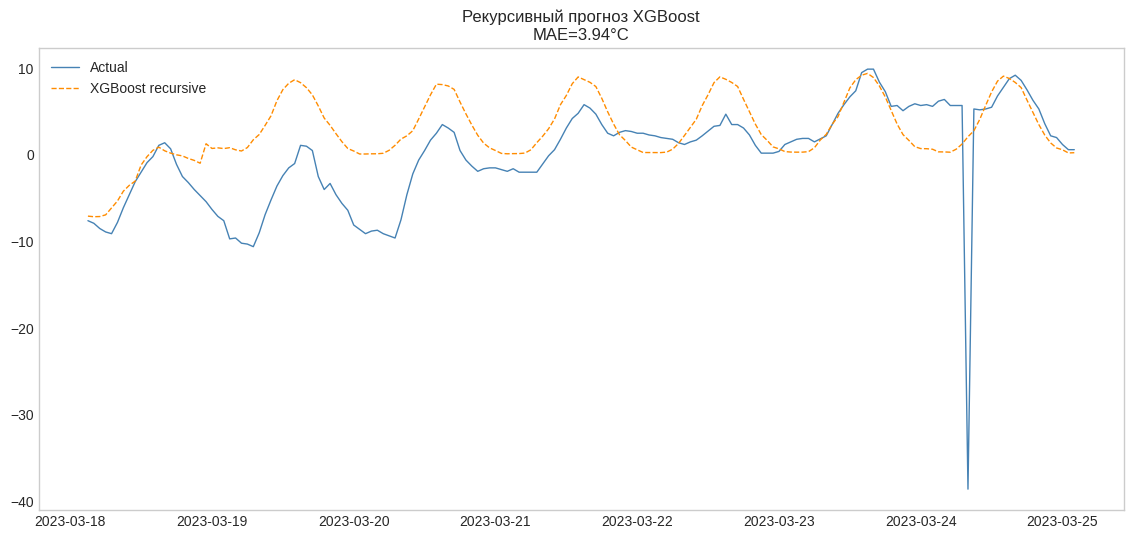

In [29]:
import optuna
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0),
        'random_state': 42,
        'n_jobs': -1
    }

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    preds = model.predict(X_val)
    mae = mean_absolute_error(y_val, preds)
    return mae

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("Best trial:")
best_trial = study.best_trial
print(f"  MAE: {best_trial.value:.4f}")
print("  Params:")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

best_xgb = xgb.XGBRegressor(**best_trial.params)
best_xgb.fit(X_train, y_train)

preds_xgb, actuals_xgb, _ = recursive_forecast(best_xgb, initial_hist, feature_cols, temp_full, horizon=168)

mask = ~np.isnan(actuals_xgb)
mae_xgb = mean_absolute_error(actuals_xgb[mask], preds_xgb[mask])

print(f"\nXGBoost recursive MAE: {mae_xgb:.2f}°C")

plt.figure(figsize=(14, 6))
plt.plot(pred_times_clean, actuals_clean, label='Actual', color='steelblue', linewidth=1)
plt.plot(pred_times_clean, preds_xgb[mask], label='XGBoost recursive', color='darkorange', linestyle='--', linewidth=1)
plt.title(f'Рекурсивный прогноз XGBoost\nMAE={mae_xgb:.2f}°C')
plt.legend()
plt.grid()
plt.show()

Тест начинается: 2024-08-09 00:00:00
Начальная история для теста: 168 часов

=== XGBoost на ТЕСТЕ (последние 168 часов) ===
MAE: 4.03°C
MAPE: 0.2225 (22.25%)
WAPE: 0.2385
Directional Accuracy: 0.7844 (78.44%)
Directional R²: 0.0260


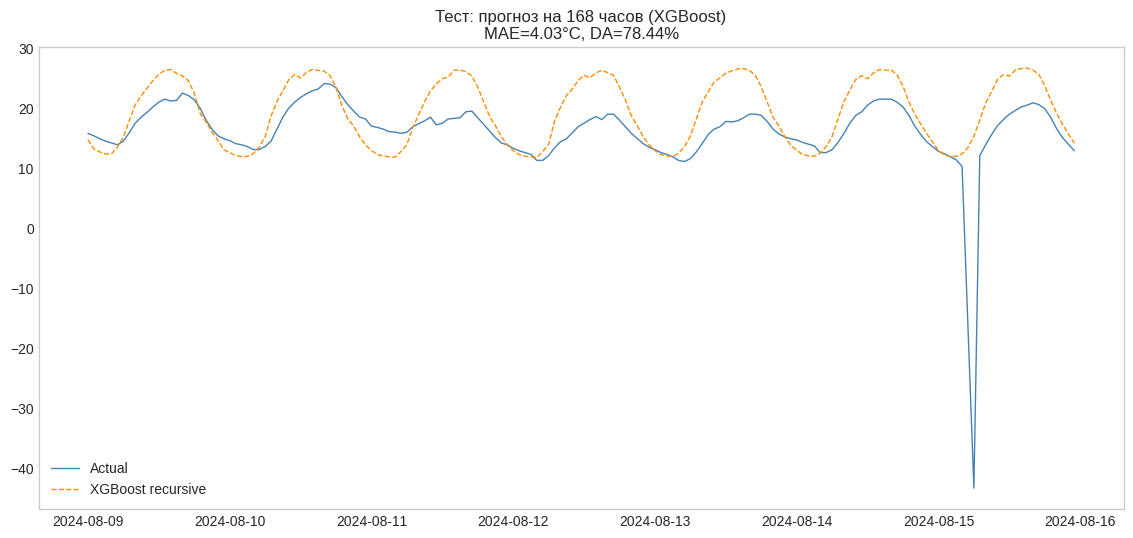


Обучаем Decision Tree и Random Forest для теста...

=== Сравнение моделей на тесте (MAE) ===
Decision Tree: 5.36°C
Random Forest: 5.96°C
XGBoost:       4.03°C


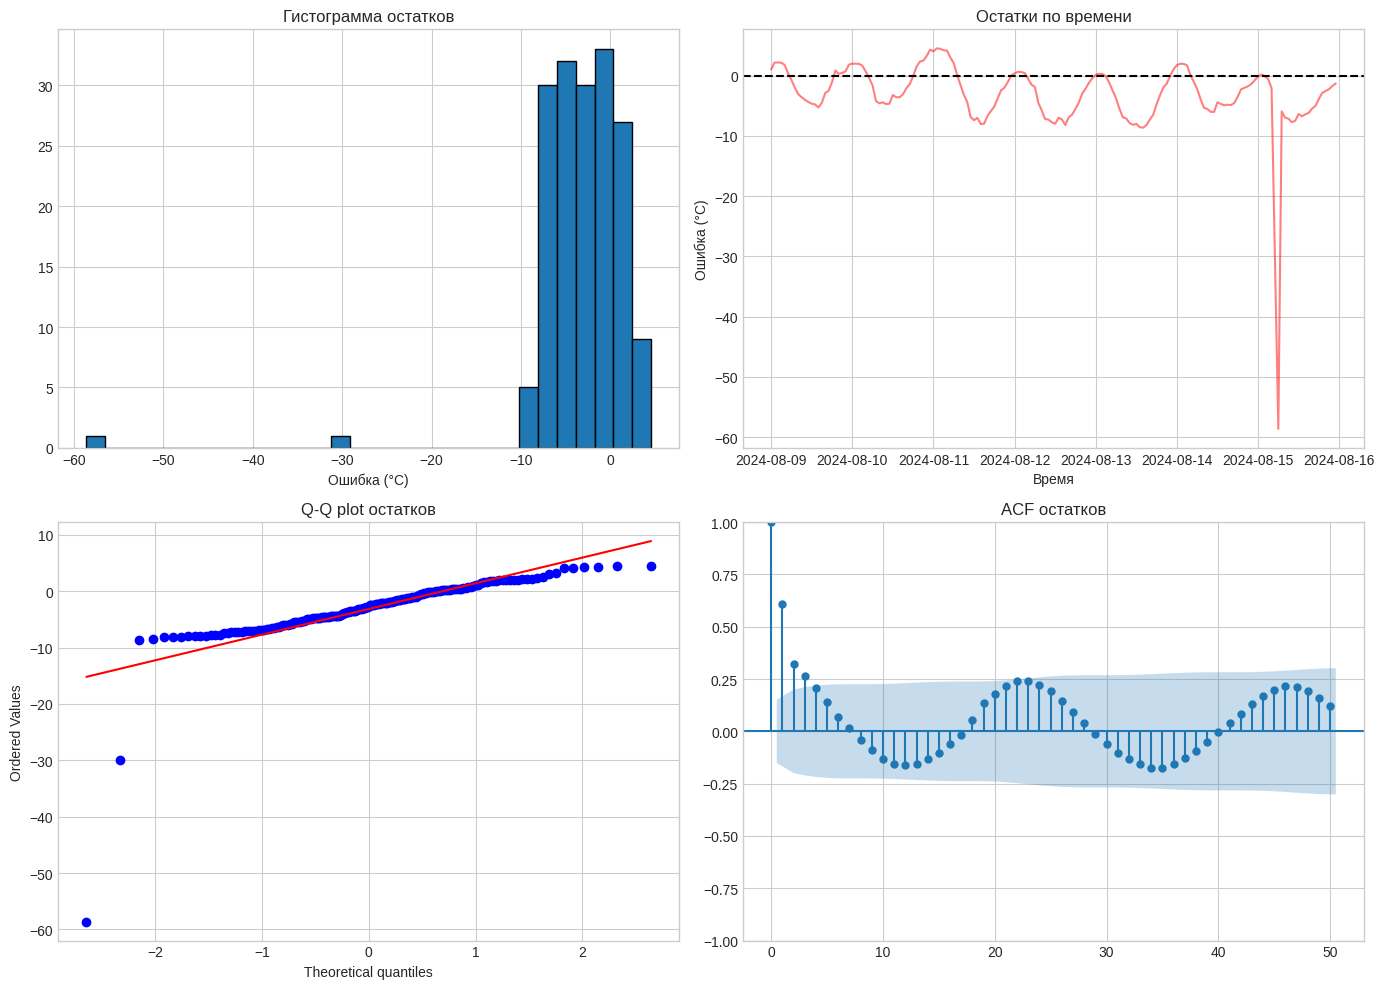


Статистика остатков:
Среднее: -3.1472°C
Стандартное отклонение: 5.8553°C
Медиана: -2.6880°C


In [32]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def directional_accuracy(y_true, y_pred):
    true_diff = np.diff(y_true)
    pred_diff = np.diff(y_pred)
    correct = np.sum((true_diff * pred_diff) > 0)
    return correct / len(true_diff) if len(true_diff) > 0 else 0

def directional_r2(y_true, y_pred):
    true_diff = np.diff(y_true)
    pred_diff = np.diff(y_pred)
    ss_res = np.sum((true_diff - pred_diff) ** 2)
    ss_tot = np.sum((true_diff - np.mean(true_diff)) ** 2)
    return 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

test_start = test_df.index[0]
initial_hist_test = temp_full.loc[:test_start - pd.Timedelta(hours=1)].iloc[-max_lag:]

print(f"Тест начинается: {test_start}")
print(f"Начальная история для теста: {len(initial_hist_test)} часов")

preds_test, actuals_test, times_test = recursive_forecast(best_xgb, initial_hist_test, feature_cols, temp_full, horizon=168)

preds_test = np.array(preds_test).flatten()
actuals_test = np.array(actuals_test).flatten()
times_test = np.array(times_test)

mask_test = ~np.isnan(actuals_test)
preds_test_clean = preds_test[mask_test]
actuals_test_clean = actuals_test[mask_test]
times_test_clean = times_test[mask_test]

mae_test = mean_absolute_error(actuals_test_clean, preds_test_clean)
mape_test = mean_absolute_percentage_error(actuals_test_clean, preds_test_clean)
wape_test = np.sum(np.abs(actuals_test_clean - preds_test_clean)) / np.sum(np.abs(actuals_test_clean))
da_test = directional_accuracy(actuals_test_clean, preds_test_clean)
dr2_test = directional_r2(actuals_test_clean, preds_test_clean)

print(f"\nXGBoost на ТЕСТЕ (последние 168 часов)")
print(f"MAE: {mae_test:.2f}°C")
print(f"MAPE: {mape_test:.4f} ({mape_test*100:.2f}%)")
print(f"WAPE: {wape_test:.4f}")
print(f"Directional Accuracy: {da_test:.4f} ({da_test*100:.2f}%)")
print(f"Directional R²: {dr2_test:.4f}")

plt.figure(figsize=(14, 6))
plt.plot(times_test_clean, actuals_test_clean, label='Actual', color='steelblue', linewidth=1)
plt.plot(times_test_clean, preds_test_clean, label='XGBoost recursive', color='darkorange', linestyle='--', linewidth=1)
plt.title(f'Тест: прогноз на 168 часов (XGBoost)\nMAE={mae_test:.2f}°C, DA={da_test:.2%}')
plt.legend()
plt.grid()
plt.show()

print("\nОбучаем Decision Tree и Random Forest для теста...")

dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
preds_dt, actuals_dt, _ = recursive_forecast(dt, initial_hist_test, feature_cols, temp_full, horizon=168)
preds_dt = np.array(preds_dt).flatten()
actuals_dt = np.array(actuals_dt).flatten()
mask_dt = ~np.isnan(actuals_dt)
mae_dt = mean_absolute_error(actuals_dt[mask_dt], preds_dt[mask_dt])

preds_rf, actuals_rf, _ = recursive_forecast(rf, initial_hist_test, feature_cols, temp_full, horizon=168)
preds_rf = np.array(preds_rf).flatten()
actuals_rf = np.array(actuals_rf).flatten()
mask_rf = ~np.isnan(actuals_rf)
mae_rf = mean_absolute_error(actuals_rf[mask_rf], preds_rf[mask_rf])

print(f"\nСравнение моделей на тесте (MAE)")
print(f"Decision Tree: {mae_dt:.2f}°C")
print(f"Random Forest: {mae_rf:.2f}°C")
print(f"XGBoost:       {mae_test:.2f}°C")

residuals = actuals_test_clean - preds_test_clean

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].hist(residuals, bins=30, edgecolor='black')
axes[0, 0].set_title('Гистограмма остатков')
axes[0, 0].set_xlabel('Ошибка (°C)')

axes[0, 1].plot(times_test_clean, residuals, color='red', alpha=0.5)
axes[0, 1].axhline(0, color='black', linestyle='--')
axes[0, 1].set_title('Остатки по времени')
axes[0, 1].set_xlabel('Время')
axes[0, 1].set_ylabel('Ошибка (°C)')

import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q plot остатков')

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=50, ax=axes[1, 1])
axes[1, 1].set_title('ACF остатков')

plt.tight_layout()
plt.show()

print(f"\nСтатистика остатков:")
print(f"Среднее: {np.mean(residuals):.4f}°C")
print(f"Стандартное отклонение: {np.std(residuals):.4f}°C")
print(f"Медиана: {np.median(residuals):.4f}°C")